# Edible or Poisonous? A Mashroom Classification Model using Decision Trees

## CART - Classification and Regrssion Tree

In [42]:
#Importing Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# Importing Dataset

dataset = pd.read_csv("mushrooms.csv")
dataset.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Exploratory Data Analysis

In [44]:
# Checking if null
dataset.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [45]:
dataset.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [46]:
dataset['class'].unique()

array(['p', 'e'], dtype=object)

In [47]:
for col in dataset.columns:
    print(dataset[col].value_counts())

class
e    4208
p    3916
Name: count, dtype: int64
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64
bruises
f    4748
t    3376
Name: count, dtype: int64
odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
gill-attachment
f    7914
a     210
Name: count, dtype: int64
gill-spacing
c    6812
w    1312
Name: count, dtype: int64
gill-size
b    5612
n    2512
Name: count, dtype: int64
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64
stalk-shape
t    4608
e    3516
Name: count, dtype: int64
stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: coun

In [48]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

<Axes: xlabel='class', ylabel='Count'>

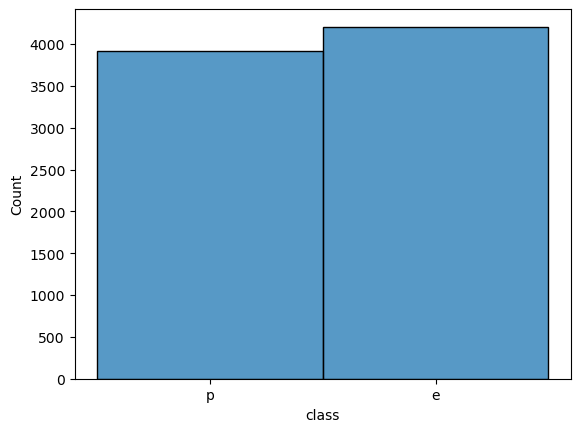

In [49]:
sns.histplot(dataset['class'])

## Seperating Features and Target

In [50]:
X = dataset.drop(['class'], axis = 1)
y = dataset['class']

In [51]:
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [52]:
# Create a dummies variable

X = pd.get_dummies(X).astype(int)
X.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


In [53]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y= encoder.fit_transform(y)
print(y)

[1 0 0 ... 0 1 0]


## Splitting data to training and test data 80% - 20%

In [54]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [55]:
X_train.shape,y_train.shape

((6499, 117), (6499,))

In [56]:
X_test.shape, y_test.shape

((1625, 117), (1625,))

## Decision Tree Creation

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.metrics import accuracy_score

## Creation of Decision Tree using Gini Index

In [58]:
# Create model using Gini

clf_gini = DecisionTreeClassifier(criterion = "gini", max_depth = 3, random_state = 0)

# fit the model
clf_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
X_train.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
7873,0,0,0,1,0,0,0,0,1,0,...,0,1,0,1,0,0,0,0,0,0
6515,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
6141,0,0,1,0,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0
2764,0,0,1,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
438,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [60]:
y_pred_gini = clf_gini.predict(X_test)

In [61]:
# Predict the value using X_train for accuracy comparision

y_pred_train_gini = clf_gini.predict(X_train)
y_pred_train_gini

array([1, 1, 1, ..., 0, 1, 0], shape=(6499,))

## Checking Overfitting

In [66]:
# Determin the accuracy score

print("Model accuracy score with criterion gini index: {0:0.4f}".format(accuracy_score(y_test,y_pred_gini)))

print("Training-set accuracy score : {0:0.4f}".format(accuracy_score(y_train,y_pred_train_gini)))

Model accuracy score with criterion gini index: 0.9809
Training-set accuracy score : 0.9863


## Plotting Graph

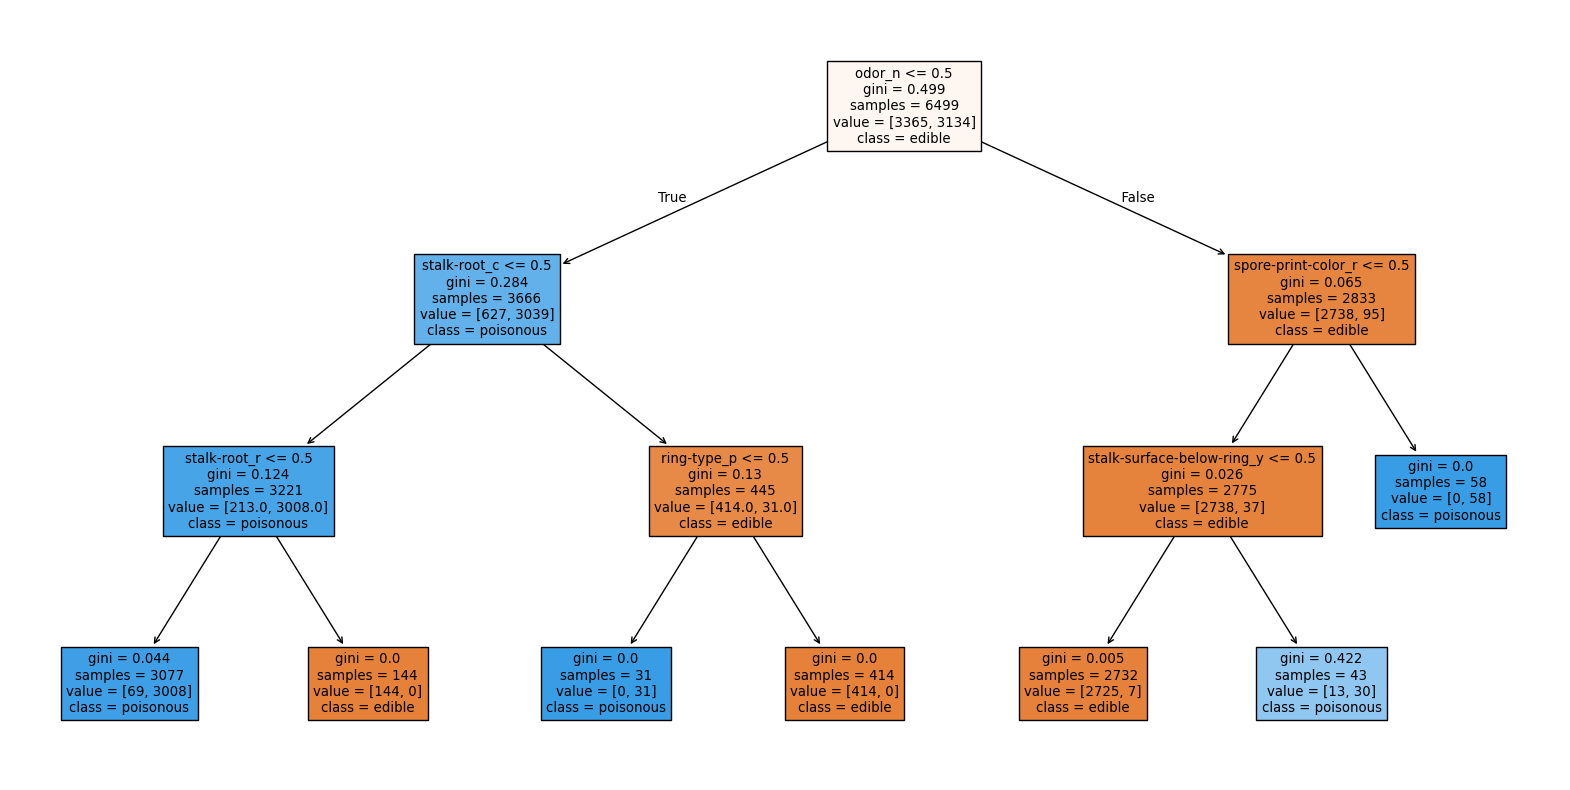

In [67]:
#from sklearn.tree import plot_tree
#plt.figure(figsize=(20,10))

#class_names = ['edible', 'poisonous']

#plot_tree(clf_gini, feature_names=feature_names, class_names=class_names, filled=True)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

class_names = ['edible', 'poisonous']
feature_names = X.columns

plot_tree(
    clf_gini,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)

plt.show()

## Creation of Decision Tree Using Entropy

In [69]:
clf_en = DecisionTreeClassifier(criterion = "entropy", max_depth = 3, random_state = 3)
clf_en.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [70]:
#Preditct the values
y_pred_en = clf_en.predict(X_test)

In [71]:
#Predict the value using X train for accuracy comparision
y_pred_train_en = clf_en.predict(X_train)

In [72]:
# Determin the accuracy score

print("Model accuracy score with criterion gini index: {0:0.4f}".format(accuracy_score(y_test,y_pred_en)))

print("Training-set accuracy score : {0:0.4f}".format(accuracy_score(y_train,y_pred_train_en)))

Model accuracy score with criterion gini index: 0.9514
Training-set accuracy score : 0.9641


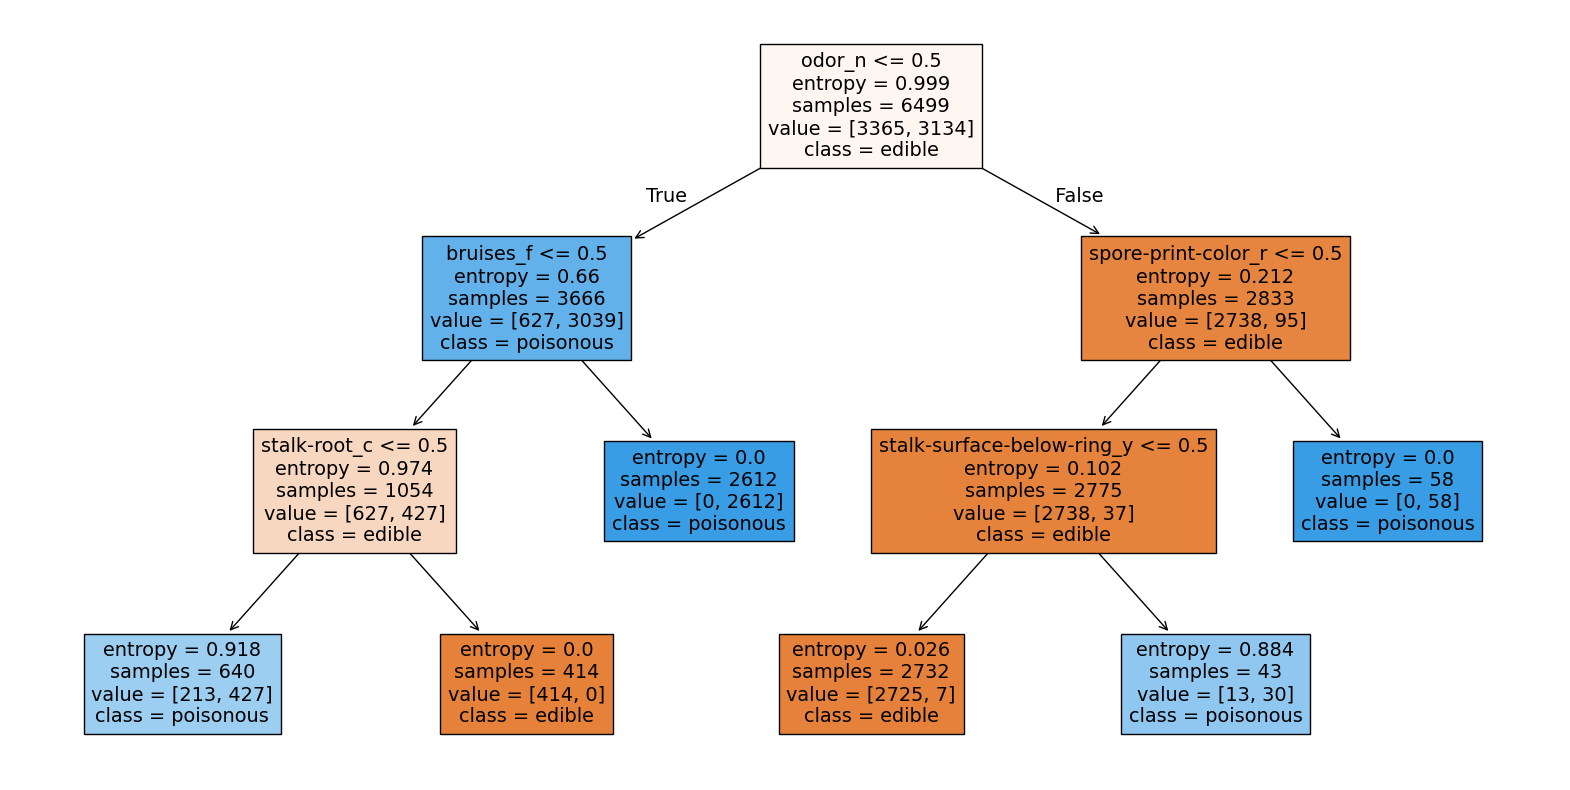

In [73]:
#from sklearn.tree import plot_tree
#plt.figure(figsize=(20,10))

#class_names = ['edible', 'poisonous']

#plot_tree(clf_gini, feature_names=feature_names, class_names=class_names, filled=True)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

class_names = ['edible', 'poisonous']
feature_names = X.columns

plot_tree(
    clf_en,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)

plt.show()

## Confusion Matrix

In [76]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import  f1_score
from sklearn.metrics import classification_report

In [77]:
cm = confusion_matrix(y_test, y_pred_en)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[765  78]
 [  1 781]]


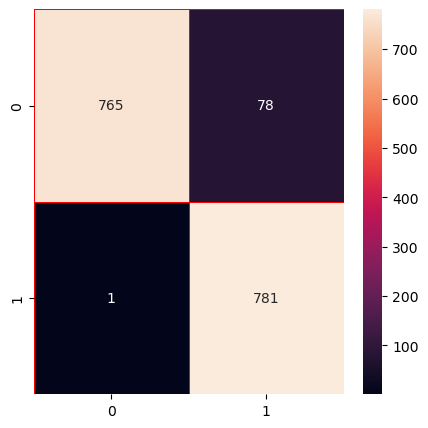

<Figure size 640x480 with 0 Axes>

In [78]:
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = 'red', fmt = '.0f', ax = ax)
plt.show()
plt.savefig("Confusionmatrix.png")

In [80]:
print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       843
           1       0.91      1.00      0.95       782

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.96      0.95      0.95      1625

